In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
HIST_PATH = Path("Results/train_history")
# N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
N_LAYERS = [3, 11, 20]

### Complete training

In [3]:
losses = {}
for layer in N_LAYERS:
    df = pd.read_csv(HIST_PATH / f"{layer}layers/train_history_{layer}layers.csv")
    train_loss = df["train_loss"].to_numpy()
    val_loss = df["val_loss"].to_numpy()
    local_dict = {"train": train_loss, "val": val_loss}
    losses[f"{layer}layers"] = local_dict    

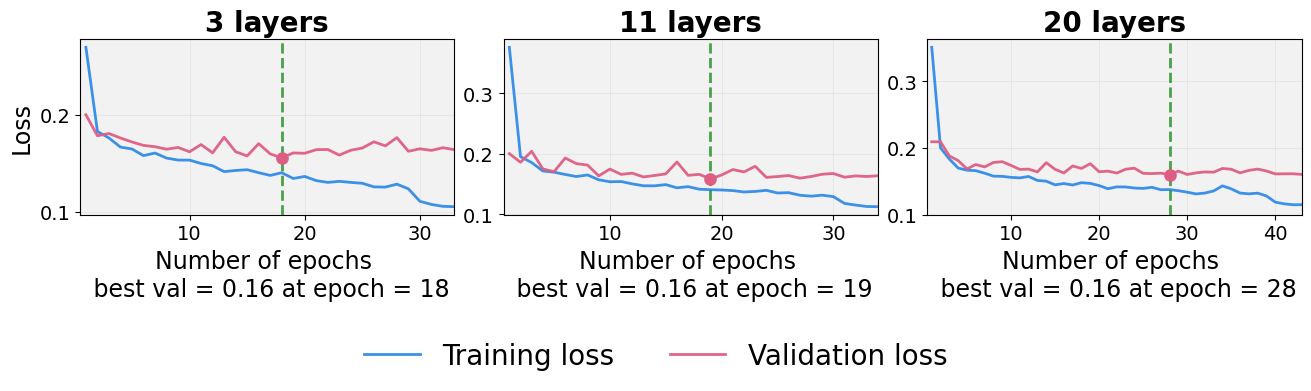

In [4]:
# plt.rcParams["font.family"] = "serif"
train_color = "#318CE7"
val_color = "#DE5D83"

fig = plt.figure(figsize=(13, 3), constrained_layout=True)

gs = fig.add_gridspec(nrows=1, ncols=3)

individual_axes = [fig.add_subplot(gs[0, c]) for c in range(3)]

for i, (fold_name, ldict) in enumerate(losses.items()):

    ax = individual_axes[i]

    train = np.asarray(ldict["train"])
    val = np.asarray(ldict["val"])

    n_epochs = len(train)
    e = np.arange(1, n_epochs + 1)
        
    best_epoch = np.argmin(val) + 1
    best_val = np.min(val)

    ax.plot(e, train, linewidth=2.0, alpha=0.95, color=train_color, label="Training loss")
    ax.plot(e, val, linewidth=2.0, alpha=0.95, color=val_color, label="Validation loss")

    ax.axvline(best_epoch, linestyle="--", linewidth=2, alpha=0.7, color="green")
    ax.scatter(best_epoch, best_val, s=65, zorder=5, color=val_color)

    ax.set_xlim([0.5, n_epochs])

    if i==0:
        ax.set_yticks([0.1, 0.2])
    else:
        ax.set_yticks([0.1, 0.2, 0.3])
        
    ax.set_xlabel(F"Number of epochs \n best val = {best_val:.2f} at epoch = {best_epoch}", 
                  fontsize=17)
    # ax.text(0.58, 0.71, 
    #         f"best val = {best_val:.3f}\nepoch = {best_epoch}", 
    #         transform=ax.transAxes, ha="right", va="bottom", fontsize=18)
    
    ax.set_title(f"{N_LAYERS[i]} layers", fontsize=20, fontweight="bold")
    ax.set_facecolor("#f2f2f2")

    # ax.text(0.58, 0.71, 
    #         f"best val = {best_val:.3f}\nepoch = {best_epoch}", 
    #         transform=ax.transAxes, ha="right", va="bottom", fontsize=18)

    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)

handles, labels = individual_axes[0].get_legend_handles_labels()

individual_axes[0].set_ylabel("Loss", fontsize=17)

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    fontsize=20,
    frameon=False
)  
# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
plt.savefig("Results/losses_combined.pdf", bbox_inches="tight")
plt.show()

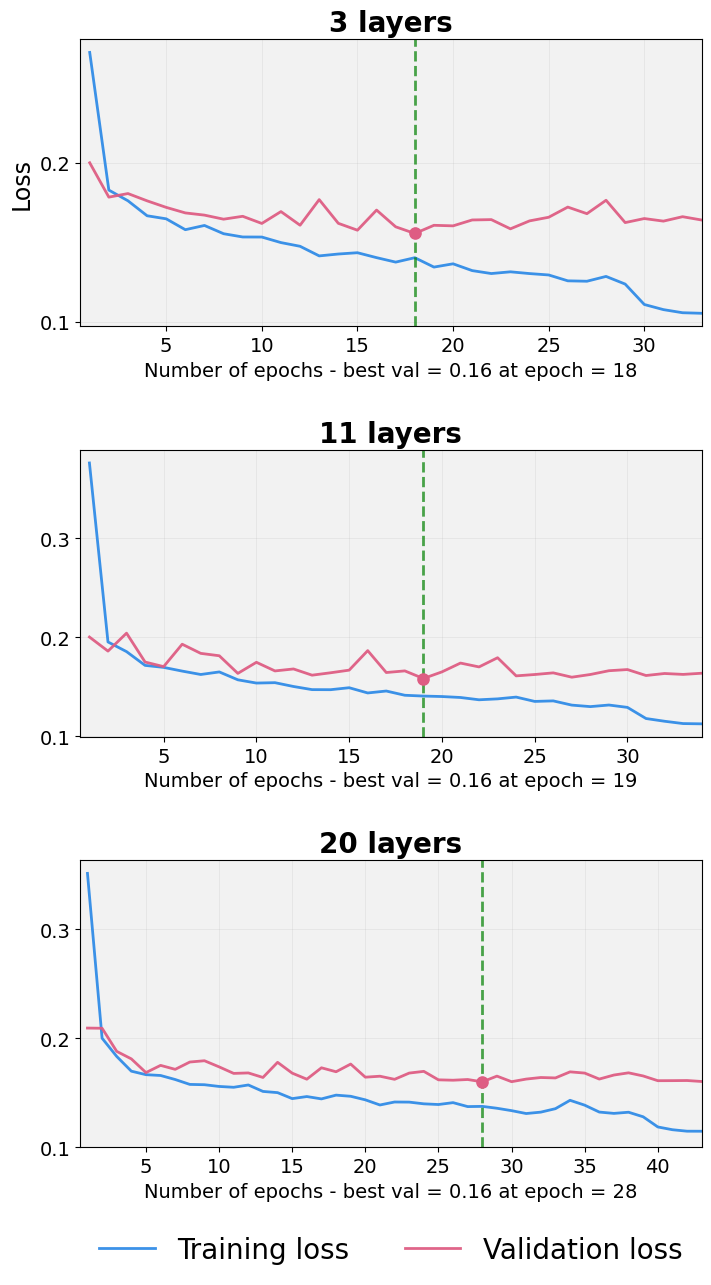

In [18]:
train_color = "#318CE7"
val_color = "#DE5D83"

fig = plt.figure(figsize=(7, 12), constrained_layout=True)

gs = fig.add_gridspec(nrows=3, ncols=1, hspace=0.1)

individual_axes = [fig.add_subplot(gs[c, 0]) for c in range(3)]

for i, (fold_name, ldict) in enumerate(losses.items()):

    ax = individual_axes[i]

    train = np.asarray(ldict["train"])
    val = np.asarray(ldict["val"])

    n_epochs = len(train)
    e = np.arange(1, n_epochs + 1)
        
    best_epoch = np.argmin(val) + 1
    best_val = np.min(val)

    ax.plot(e, train, linewidth=2.0, alpha=0.95, color=train_color, label="Training loss")
    ax.plot(e, val, linewidth=2.0, alpha=0.95, color=val_color, label="Validation loss")

    ax.axvline(best_epoch, linestyle="--", linewidth=2, alpha=0.7, color="green")
    ax.scatter(best_epoch, best_val, s=65, zorder=5, color=val_color)

    ax.set_xlim([0.5, n_epochs])

    if i==0:
        ax.set_yticks([0.1, 0.2])
    else:
        ax.set_yticks([0.1, 0.2, 0.3])
        
    ax.set_xlabel(F"Number of epochs - best val = {best_val:.2f} at epoch = {best_epoch}", 
                  fontsize=14)
    # ax.text(0.58, 0.71, 
    #         f"best val = {best_val:.3f}\nepoch = {best_epoch}", 
    #         transform=ax.transAxes, ha="right", va="bottom", fontsize=18)
    
    ax.set_title(f"{N_LAYERS[i]} layers", fontsize=20, fontweight="bold")
    ax.set_facecolor("#f2f2f2")

    # ax.text(0.58, 0.71, 
    #         f"best val = {best_val:.3f}\nepoch = {best_epoch}", 
    #         transform=ax.transAxes, ha="right", va="bottom", fontsize=18)

    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.tick_params(axis='both', labelsize=14)

handles, labels = individual_axes[0].get_legend_handles_labels()

individual_axes[0].set_ylabel("Loss", fontsize=17)

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.55, -0.07),
    ncol=2,
    fontsize=20,
    frameon=False
)  
# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
plt.savefig("Results/losses_combined_vertical.pdf", bbox_inches="tight")
plt.show()

### Retraining 11 layers